<a href="https://colab.research.google.com/github/Navenkumar-Balasubramaniam/00-General/blob/main/06%20Data%20manipulation%20excercise/DataManipulationGroup7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import requests
import pandas as pd


#importing raw data
custtravel_url = "https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/06%20Data%20manipulation%20excercise/Custtravel.dat"
holtravel_url = "https://raw.githubusercontent.com/Navenkumar-Balasubramaniam/00-General/refs/heads/main/06%20Data%20manipulation%20excercise/Holtravel.dat"

In [24]:
custtravel = requests.get(custtravel_url)
holtravel = requests.get(holtravel_url)

custtravel_text = custtravel.text
holtravel_text = holtravel.text

#Split full text into lines
#Take only first 10 lines
#Loop over each line
#Number lines starting from 1

for i , line in enumerate(custtravel_text.splitlines()[:10],1):
  print(f"{i}:{line}")

for i , line in enumerate(holtravel_text.splitlines()[:10],1):
  print(f"{i}:{line}")

1:CUSTID;NAME;DOB;GENDER;REGION;PASTHOL;HOLCOST;NIGHTS;TRAVDATE;HOLCODE
2:GS101001;Roberta Godfrey;02/02/1966;0;Northern Ireland;3;520.0;21;06/09/1998;CAF3108
3:GS101002;Joan Ranger;14/07/1953;0;South West;1;1450.0;7;04/09/1998;CAF3112
4:GS101003;Mrs B. Empire;29/04/1961;0;North West;1;510.0;10;04/07/1998;CAF3108
5:GS101004;Mr W. Gummage;28/09/1958;1;Scotland;4;1570.0;14;21/09/1998;CAF3108
6:GS101005;Mr B. Emw;19/05/1925;1;East Anglia;1;450.0;10;12/08/1998;CAF3100
7:GS101006;Mandy Stevens;20/05/1948; ;North East;1;640.0;10;22/08/1998;CAF3113
8:GS101007;Ivor Squareye;25/09/1962;1;North East;1;834.0;7;16/09/1998;CAF3113
9:GS101008;Wendy Pence;03/01/1956;0;North East;4;660.0;21;28/07/1998;CAF3108
10:GS101009;Mr K.N. Owledgable;14/08/1966;1;North East;6;2650.0;21;31/08/1998;CAF3115
1:holidaycode;COUNTRY;POOL;ACCOMMODATION;DISTBEACH
2:CAF3100;GREECE;No;CABIN;5
3:CAF3103;GREECE;Yes;CABIN;15
4:CAF3104;GREECE;No;;10
5:CAF3105;GREECE;No;APARTMENT;2
6:CAF3106;SPAIN;Yes;APARTMENT;1
7:CAF3107;SPAI

In [25]:
custtravel_df = pd.read_csv(custtravel_url,sep=";")
holtravel_df = pd.read_csv(holtravel_url,sep=";")

In [26]:
custtravel_df.head()

,CUSTID,NAME,DOB,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE
0,GS101001,Roberta Godfrey,02/02/1966,0,Northern Ireland,3,520.0,21,06/09/1998,CAF3108
1,GS101002,Joan Ranger,14/07/1953,0,South West,1,1450.0,7,04/09/1998,CAF3112
2,GS101003,Mrs B. Empire,29/04/1961,0,North West,1,510.0,10,04/07/1998,CAF3108
3,GS101004,Mr W. Gummage,28/09/1958,1,Scotland,4,1570.0,14,21/09/1998,CAF3108
4,GS101005,Mr B. Emw,19/05/1925,1,East Anglia,1,450.0,10,12/08/1998,CAF3100


In [27]:
holtravel_df.head()

,holidaycode,COUNTRY,POOL,ACCOMMODATION,DISTBEACH
0,CAF3100,GREECE,No,CABIN,5
1,CAF3103,GREECE,Yes,CABIN,15
2,CAF3104,GREECE,No,NaN,10
3,CAF3105,GREECE,No,APARTMENT,2
4,CAF3106,SPAIN,Yes,APARTMENT,1


In [28]:
custtravel_df.shape

(152, 10)

In [29]:
holtravel_df.shape

(19, 5)

In [30]:
#Task 1 - Joining the datasets

CustandHol = pd.merge(custtravel_df,
                      holtravel_df,
                      left_on="HOLCODE",
                      right_on="holidaycode",
                      how="left")
CustandHol.drop(columns="holidaycode",inplace=True)
CustandHol.head(10)

,CUSTID,NAME,DOB,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,COUNTRY,POOL,ACCOMMODATION,DISTBEACH
0,GS101001,Roberta Godfrey,02/02/1966,0,Northern Ireland,3,520.0,21,06/09/1998,CAF3108,SPAIN,No,HOTEL,5
1,GS101002,Joan Ranger,14/07/1953,0,South West,1,1450.0,7,04/09/1998,CAF3112,SPAIN,Yes,HOTEL,2
2,GS101003,Mrs B. Empire,29/04/1961,0,North West,1,510.0,10,04/07/1998,CAF3108,SPAIN,No,HOTEL,5
3,GS101004,Mr W. Gummage,28/09/1958,1,Scotland,4,1570.0,14,21/09/1998,CAF3108,SPAIN,No,HOTEL,5
4,GS101005,Mr B. Emw,19/05/1925,1,East Anglia,1,450.0,10,12/08/1998,CAF3100,GREECE,No,CABIN,5
5,GS101006,Mandy Stevens,20/05/1948,,North East,1,640.0,10,22/08/1998,CAF3113,GERMANY,Yes,CABIN,10
6,GS101007,Ivor Squareye,25/09/1962,1,North East,1,834.0,7,16/09/1998,CAF3113,GERMANY,Yes,CABIN,10
7,GS101008,Wendy Pence,03/01/1956,0,North East,4,660.0,21,28/07/1998,CAF3108,SPAIN,No,HOTEL,5
8,GS101009,Mr K.N. Owledgable,14/08/1966,1,North East,6,2650.0,21,31/08/1998,CAF3115,ITALY,Yes,APARTMENT,1
9,GS101010,Jill Banker,02/07/1926,0,North East,4,1130.0,14,05/07/1998,CAF3114,ITALY,Yes,APARTMENT,5


In [31]:
#Sanity check
for col in ["COUNTRY","POOL","ACCOMMODATION","DISTBEACH"] :
   print(CustandHol[col].isna().sum())
   print(CustandHol[col].describe())

for col in ["COUNTRY","POOL","ACCOMMODATION","DISTBEACH"] :
   print(holtravel_df[col].isna().sum())



0
count       152
unique        4
top       SPAIN
freq         55
Name: COUNTRY, dtype: object
0
count     152
unique      2
top       Yes
freq      101
Name: POOL, dtype: object
1
count       151
unique        3
top       HOTEL
freq         72
Name: ACCOMMODATION, dtype: object
0
count    152.000000
mean       4.059211
std        2.800742
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       10.000000
Name: DISTBEACH, dtype: float64
0
0
1
0


In [32]:
#Task 2 - Correction
#Rename DOB

CustandHol = CustandHol.rename(columns = {"DOB":"Date of Birth"})

CustandHol.head()

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,COUNTRY,POOL,ACCOMMODATION,DISTBEACH
0,GS101001,Roberta Godfrey,02/02/1966,0,Northern Ireland,3,520.0,21,06/09/1998,CAF3108,SPAIN,No,HOTEL,5
1,GS101002,Joan Ranger,14/07/1953,0,South West,1,1450.0,7,04/09/1998,CAF3112,SPAIN,Yes,HOTEL,2
2,GS101003,Mrs B. Empire,29/04/1961,0,North West,1,510.0,10,04/07/1998,CAF3108,SPAIN,No,HOTEL,5
3,GS101004,Mr W. Gummage,28/09/1958,1,Scotland,4,1570.0,14,21/09/1998,CAF3108,SPAIN,No,HOTEL,5
4,GS101005,Mr B. Emw,19/05/1925,1,East Anglia,1,450.0,10,12/08/1998,CAF3100,GREECE,No,CABIN,5


In [33]:
#Date format

CustandHol["Date of Birth"].dtype

dtype('O')

In [34]:
CustandHol["TRAVDATE"].dtype

dtype('O')

In [35]:
CustandHol["Date of Birth"] = pd.to_datetime(CustandHol['Date of Birth'],format="%d/%m/%Y")
CustandHol["TRAVDATE"] = pd.to_datetime(CustandHol['TRAVDATE'],format="%d/%m/%Y")

In [36]:
CustandHol["Date of Birth"].dtype

dtype('<M8[ns]')

In [37]:
CustandHol["TRAVDATE"].dtype

dtype('<M8[ns]')

In [38]:
CustandHol.head()

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,COUNTRY,POOL,ACCOMMODATION,DISTBEACH
0,GS101001,Roberta Godfrey,1966-02-02,0,Northern Ireland,3,520.0,21,1998-09-06,CAF3108,SPAIN,No,HOTEL,5
1,GS101002,Joan Ranger,1953-07-14,0,South West,1,1450.0,7,1998-09-04,CAF3112,SPAIN,Yes,HOTEL,2
2,GS101003,Mrs B. Empire,1961-04-29,0,North West,1,510.0,10,1998-07-04,CAF3108,SPAIN,No,HOTEL,5
3,GS101004,Mr W. Gummage,1958-09-28,1,Scotland,4,1570.0,14,1998-09-21,CAF3108,SPAIN,No,HOTEL,5
4,GS101005,Mr B. Emw,1925-05-19,1,East Anglia,1,450.0,10,1998-08-12,CAF3100,GREECE,No,CABIN,5


In [39]:
CustandHol.loc[CustandHol["NAME"] == "Mr Lux"]

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,COUNTRY,POOL,ACCOMMODATION,DISTBEACH
28,GS101030,Mr Lux,1961-07-24,0,Wales,4,1190.0,10,1998-07-05,CAF3114,ITALY,Yes,APARTMENT,5
83,GS101082,Mr Lux,1953-11-17,1,North West,2,1400.0,10,1998-08-22,CAF3112,SPAIN,Yes,HOTEL,2
106,GS101105,Mr Lux,1978-06-26,1,North East,1,1660.0,14,1998-09-07,CAF3120,GREECE,Yes,APARTMENT,5


In [40]:
#Gender type

pd.set_option("display.max_rows", None)
#pd.reset_option("display.max_rows")
CustandHol.groupby(["GENDER","NAME"]).size()
CustandHol["GENDER"] = pd.to_numeric(CustandHol["GENDER"],errors = 'coerce')
CustandHol["Gender_type"] = CustandHol["GENDER"].map({
    0: "Female",
    1: "Male"
})
CustandHol["GENDER"].dtype


dtype('float64')

In [41]:
#Replace missing values
CustandHol['ACCOMMODATION'] = CustandHol['ACCOMMODATION'].fillna("NA")

CustandHol.groupby(['ACCOMMODATION']).size()



,0
ACCOMMODATION,
APARTMENT,57
CABIN,22
HOTEL,72
NA,1


In [42]:
CustandHol['HOLCOST'].dtype

CustandHol['HOLCOST'].describe()

CustandHol['HOLCOST_1'] = pd.to_numeric(CustandHol['HOLCOST'],errors='coerce')

CustandHol['HOLCOST_1'].describe()

,HOLCOST_1
count,150.000000
mean,1635.853333
std,1520.745655
min,239.000000
25%,526.250000
50%,1240.000000
75%,2045.000000
max,8660.000000


In [43]:
CustandHol.loc[CustandHol["HOLCOST_1"].isnull(),:]

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,COUNTRY,POOL,ACCOMMODATION,DISTBEACH,Gender_type,HOLCOST_1
13,GS101014,Mr B. Ilder,1910-04-28,1.0,South West,5,$null$,14,1998-09-03,CAF3113,GERMANY,Yes,CABIN,10,Male,NaN
101,GS101100,Kathy Beard,1963-03-14,0.0,Northern Ireland,2,$null$,14,1998-09-29,CAF3117,ITALY,Yes,HOTEL,6,Female,NaN


In [44]:
#Task 3

#Remove values outside 1.5 IQR for HOLCOST

q1 = CustandHol['HOLCOST_1'].quantile(0.25)
print(q1)
q3 = CustandHol['HOLCOST_1'].quantile(0.75)
print(q3)
iqr = q3 - q1
print(iqr)

526.25
2045.0
1518.75


In [45]:
CustandHol_clean = CustandHol.loc[(CustandHol['HOLCOST_1'].between(q1 - 1.5*iqr, q3 + 1.5*iqr)),:].copy()

In [46]:
CustandHol_clean.shape

(142, 16)

In [47]:
CustandHol_clean.head(10)

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,COUNTRY,POOL,ACCOMMODATION,DISTBEACH,Gender_type,HOLCOST_1
0,GS101001,Roberta Godfrey,1966-02-02,0.0,Northern Ireland,3,520.0,21,1998-09-06,CAF3108,SPAIN,No,HOTEL,5,Female,520.0
1,GS101002,Joan Ranger,1953-07-14,0.0,South West,1,1450.0,7,1998-09-04,CAF3112,SPAIN,Yes,HOTEL,2,Female,1450.0
2,GS101003,Mrs B. Empire,1961-04-29,0.0,North West,1,510.0,10,1998-07-04,CAF3108,SPAIN,No,HOTEL,5,Female,510.0
3,GS101004,Mr W. Gummage,1958-09-28,1.0,Scotland,4,1570.0,14,1998-09-21,CAF3108,SPAIN,No,HOTEL,5,Male,1570.0
4,GS101005,Mr B. Emw,1925-05-19,1.0,East Anglia,1,450.0,10,1998-08-12,CAF3100,GREECE,No,CABIN,5,Male,450.0
5,GS101006,Mandy Stevens,1948-05-20,NaN,North East,1,640.0,10,1998-08-22,CAF3113,GERMANY,Yes,CABIN,10,NaN,640.0
6,GS101007,Ivor Squareye,1962-09-25,1.0,North East,1,834.0,7,1998-09-16,CAF3113,GERMANY,Yes,CABIN,10,Male,834.0
7,GS101008,Wendy Pence,1956-01-03,0.0,North East,4,660.0,21,1998-07-28,CAF3108,SPAIN,No,HOTEL,5,Female,660.0
8,GS101009,Mr K.N. Owledgable,1966-08-14,1.0,North East,6,2650.0,21,1998-08-31,CAF3115,ITALY,Yes,APARTMENT,1,Male,2650.0
9,GS101010,Jill Banker,1926-07-02,0.0,North East,4,1130.0,14,1998-07-05,CAF3114,ITALY,Yes,APARTMENT,5,Female,1130.0


In [48]:
#Standardise Holcost

CustandHol_clean["Z_HOLCOST"] = round(((CustandHol_clean['HOLCOST_1'] - CustandHol_clean['HOLCOST_1'].mean())/CustandHol_clean['HOLCOST_1'].std()),3)

In [49]:
CustandHol_clean.head(10)

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,COUNTRY,POOL,ACCOMMODATION,DISTBEACH,Gender_type,HOLCOST_1,Z_HOLCOST
0,GS101001,Roberta Godfrey,1966-02-02,0.0,Northern Ireland,3,520.0,21,1998-09-06,CAF3108,SPAIN,No,HOTEL,5,Female,520.0,-0.871
1,GS101002,Joan Ranger,1953-07-14,0.0,South West,1,1450.0,7,1998-09-04,CAF3112,SPAIN,Yes,HOTEL,2,Female,1450.0,0.090
2,GS101003,Mrs B. Empire,1961-04-29,0.0,North West,1,510.0,10,1998-07-04,CAF3108,SPAIN,No,HOTEL,5,Female,510.0,-0.881
3,GS101004,Mr W. Gummage,1958-09-28,1.0,Scotland,4,1570.0,14,1998-09-21,CAF3108,SPAIN,No,HOTEL,5,Male,1570.0,0.214
4,GS101005,Mr B. Emw,1925-05-19,1.0,East Anglia,1,450.0,10,1998-08-12,CAF3100,GREECE,No,CABIN,5,Male,450.0,-0.943
5,GS101006,Mandy Stevens,1948-05-20,NaN,North East,1,640.0,10,1998-08-22,CAF3113,GERMANY,Yes,CABIN,10,NaN,640.0,-0.747
6,GS101007,Ivor Squareye,1962-09-25,1.0,North East,1,834.0,7,1998-09-16,CAF3113,GERMANY,Yes,CABIN,10,Male,834.0,-0.546
7,GS101008,Wendy Pence,1956-01-03,0.0,North East,4,660.0,21,1998-07-28,CAF3108,SPAIN,No,HOTEL,5,Female,660.0,-0.726
8,GS101009,Mr K.N. Owledgable,1966-08-14,1.0,North East,6,2650.0,21,1998-08-31,CAF3115,ITALY,Yes,APARTMENT,1,Male,2650.0,1.329
9,GS101010,Jill Banker,1926-07-02,0.0,North East,4,1130.0,14,1998-07-05,CAF3114,ITALY,Yes,APARTMENT,5,Female,1130.0,-0.241


In [50]:
#Extract month from DOB

CustandHol_clean["Birthday_Month"] = CustandHol_clean['Date of Birth'].dt.month_name()

In [51]:
#Age
today = pd.Timestamp.today()
CustandHol_clean['Age'] = (
    today.year - CustandHol_clean['Date of Birth'].dt.year
    - (
        (today.month < CustandHol_clean['Date of Birth'].dt.month) |
        (
            (today.month == CustandHol_clean['Date of Birth'].dt.month) &
            (today.day < CustandHol_clean['Date of Birth'].dt.day)
        )
    )
)

CustandHol_clean.head()

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,COUNTRY,POOL,ACCOMMODATION,DISTBEACH,Gender_type,HOLCOST_1,Z_HOLCOST,Birthday_Month,Age
0,GS101001,Roberta Godfrey,1966-02-02,0.0,Northern Ireland,3,520.0,21,1998-09-06,CAF3108,SPAIN,No,HOTEL,5,Female,520.0,-0.871,February,59
1,GS101002,Joan Ranger,1953-07-14,0.0,South West,1,1450.0,7,1998-09-04,CAF3112,SPAIN,Yes,HOTEL,2,Female,1450.0,0.090,July,72
2,GS101003,Mrs B. Empire,1961-04-29,0.0,North West,1,510.0,10,1998-07-04,CAF3108,SPAIN,No,HOTEL,5,Female,510.0,-0.881,April,64
3,GS101004,Mr W. Gummage,1958-09-28,1.0,Scotland,4,1570.0,14,1998-09-21,CAF3108,SPAIN,No,HOTEL,5,Male,1570.0,0.214,September,67
4,GS101005,Mr B. Emw,1925-05-19,1.0,East Anglia,1,450.0,10,1998-08-12,CAF3100,GREECE,No,CABIN,5,Male,450.0,-0.943,May,100


In [52]:
CustandHol_clean["Age"].describe()

,Age
count,142.000000
mean,67.654930
std,15.464921
min,45.000000
25%,55.000000
50%,64.500000
75%,77.750000
max,110.000000


In [53]:
CustandHol_clean = CustandHol_clean.loc[CustandHol_clean["Age"] >= 18,:]

In [54]:
from sklearn.preprocessing import OneHotEncoder

In [55]:
ohe = OneHotEncoder(sparse_output=False)
cat_arr = ohe.fit_transform(CustandHol_clean[["COUNTRY"]])

In [56]:
col_names = ohe.get_feature_names_out(["COUNTRY"])

In [57]:
encoded_df = pd.DataFrame(cat_arr,
                          columns = col_names)

In [58]:
CustandHol_clean = pd.concat([CustandHol_clean,encoded_df],axis = 1)

In [59]:
CustandHol_clean.head()

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,...,DISTBEACH,Gender_type,HOLCOST_1,Z_HOLCOST,Birthday_Month,Age,COUNTRY_GERMANY,COUNTRY_GREECE,COUNTRY_ITALY,COUNTRY_SPAIN
0,GS101001,Roberta Godfrey,1966-02-02,0.0,Northern Ireland,3.0,520.0,21.0,1998-09-06,CAF3108,...,5.0,Female,520.0,-0.871,February,59.0,0.0,0.0,0.0,1.0
1,GS101002,Joan Ranger,1953-07-14,0.0,South West,1.0,1450.0,7.0,1998-09-04,CAF3112,...,2.0,Female,1450.0,0.090,July,72.0,0.0,0.0,0.0,1.0
2,GS101003,Mrs B. Empire,1961-04-29,0.0,North West,1.0,510.0,10.0,1998-07-04,CAF3108,...,5.0,Female,510.0,-0.881,April,64.0,0.0,0.0,0.0,1.0
3,GS101004,Mr W. Gummage,1958-09-28,1.0,Scotland,4.0,1570.0,14.0,1998-09-21,CAF3108,...,5.0,Male,1570.0,0.214,September,67.0,0.0,0.0,0.0,1.0
4,GS101005,Mr B. Emw,1925-05-19,1.0,East Anglia,1.0,450.0,10.0,1998-08-12,CAF3100,...,5.0,Male,450.0,-0.943,May,100.0,0.0,1.0,0.0,0.0


In [60]:
#Travel started on Friday or Saturday and Destination was Spain

CustandHol_clean["TRAVDAY"] = CustandHol_clean["TRAVDATE"].dt.day_name()

In [62]:
CustandHol_clean["WEEKEND_SPAIN"] = (
    (CustandHol_clean['TRAVDAY'].isin(["Friday","Saturday"])) &
    (CustandHol_clean['COUNTRY_SPAIN'] == 1)
).astype(int)

In [63]:
CustandHol_clean.head()

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,...,HOLCOST_1,Z_HOLCOST,Birthday_Month,Age,COUNTRY_GERMANY,COUNTRY_GREECE,COUNTRY_ITALY,COUNTRY_SPAIN,TRAVDAY,WEEKEND_SPAIN
0,GS101001,Roberta Godfrey,1966-02-02,0.0,Northern Ireland,3.0,520.0,21.0,1998-09-06,CAF3108,...,520.0,-0.871,February,59.0,0.0,0.0,0.0,1.0,Sunday,0
1,GS101002,Joan Ranger,1953-07-14,0.0,South West,1.0,1450.0,7.0,1998-09-04,CAF3112,...,1450.0,0.090,July,72.0,0.0,0.0,0.0,1.0,Friday,1
2,GS101003,Mrs B. Empire,1961-04-29,0.0,North West,1.0,510.0,10.0,1998-07-04,CAF3108,...,510.0,-0.881,April,64.0,0.0,0.0,0.0,1.0,Saturday,1
3,GS101004,Mr W. Gummage,1958-09-28,1.0,Scotland,4.0,1570.0,14.0,1998-09-21,CAF3108,...,1570.0,0.214,September,67.0,0.0,0.0,0.0,1.0,Monday,0
4,GS101005,Mr B. Emw,1925-05-19,1.0,East Anglia,1.0,450.0,10.0,1998-08-12,CAF3100,...,450.0,-0.943,May,100.0,0.0,1.0,0.0,0.0,Wednesday,0


In [65]:
#Create the three typical transformations of HOLCOST variable (LN, SQRT, Inverse)
import numpy as np
CustandHol_clean["HOLCOST_LN"] = np.log(CustandHol_clean["HOLCOST_1"])
CustandHol_clean["HOLCOST_SQRT"] = np.sqrt(CustandHol_clean["HOLCOST_1"])
CustandHol_clean["HOLCOST_INV"] = 1 / CustandHol_clean["HOLCOST_1"]


In [67]:
CustandHol_clean.head(10)

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,...,Age,COUNTRY_GERMANY,COUNTRY_GREECE,COUNTRY_ITALY,COUNTRY_SPAIN,TRAVDAY,WEEKEND_SPAIN,HOLCOST_LN,HOLCOST_SQRT,HOLCOST_INV
0,GS101001,Roberta Godfrey,1966-02-02,0.0,Northern Ireland,3.0,520.0,21.0,1998-09-06,CAF3108,...,59.0,0.0,0.0,0.0,1.0,Sunday,0,6.253829,22.803509,0.001923
1,GS101002,Joan Ranger,1953-07-14,0.0,South West,1.0,1450.0,7.0,1998-09-04,CAF3112,...,72.0,0.0,0.0,0.0,1.0,Friday,1,7.279319,38.078866,0.000690
2,GS101003,Mrs B. Empire,1961-04-29,0.0,North West,1.0,510.0,10.0,1998-07-04,CAF3108,...,64.0,0.0,0.0,0.0,1.0,Saturday,1,6.234411,22.583180,0.001961
3,GS101004,Mr W. Gummage,1958-09-28,1.0,Scotland,4.0,1570.0,14.0,1998-09-21,CAF3108,...,67.0,0.0,0.0,0.0,1.0,Monday,0,7.358831,39.623226,0.000637
4,GS101005,Mr B. Emw,1925-05-19,1.0,East Anglia,1.0,450.0,10.0,1998-08-12,CAF3100,...,100.0,0.0,1.0,0.0,0.0,Wednesday,0,6.109248,21.213203,0.002222
5,GS101006,Mandy Stevens,1948-05-20,NaN,North East,1.0,640.0,10.0,1998-08-22,CAF3113,...,77.0,1.0,0.0,0.0,0.0,Saturday,0,6.461468,25.298221,0.001563
6,GS101007,Ivor Squareye,1962-09-25,1.0,North East,1.0,834.0,7.0,1998-09-16,CAF3113,...,63.0,1.0,0.0,0.0,0.0,Wednesday,0,6.726233,28.879058,0.001199
7,GS101008,Wendy Pence,1956-01-03,0.0,North East,4.0,660.0,21.0,1998-07-28,CAF3108,...,70.0,0.0,0.0,0.0,1.0,Tuesday,0,6.492240,25.690465,0.001515
8,GS101009,Mr K.N. Owledgable,1966-08-14,1.0,North East,6.0,2650.0,21.0,1998-08-31,CAF3115,...,59.0,0.0,0.0,1.0,0.0,Monday,0,7.882315,51.478151,0.000377
9,GS101010,Jill Banker,1926-07-02,0.0,North East,4.0,1130.0,14.0,1998-07-05,CAF3114,...,99.0,0.0,0.0,1.0,0.0,Sunday,0,7.029973,33.615473,0.000885


In [68]:
#Extract Customer Surname from NAME variable

CustandHol_clean["SURNAME"] = CustandHol_clean["NAME"].str.strip().str.split().str[-1].replace("",np.nan)

In [69]:
CustandHol_clean.head(10)

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,...,COUNTRY_GERMANY,COUNTRY_GREECE,COUNTRY_ITALY,COUNTRY_SPAIN,TRAVDAY,WEEKEND_SPAIN,HOLCOST_LN,HOLCOST_SQRT,HOLCOST_INV,SURNAME
0,GS101001,Roberta Godfrey,1966-02-02,0.0,Northern Ireland,3.0,520.0,21.0,1998-09-06,CAF3108,...,0.0,0.0,0.0,1.0,Sunday,0,6.253829,22.803509,0.001923,Godfrey
1,GS101002,Joan Ranger,1953-07-14,0.0,South West,1.0,1450.0,7.0,1998-09-04,CAF3112,...,0.0,0.0,0.0,1.0,Friday,1,7.279319,38.078866,0.000690,Ranger
2,GS101003,Mrs B. Empire,1961-04-29,0.0,North West,1.0,510.0,10.0,1998-07-04,CAF3108,...,0.0,0.0,0.0,1.0,Saturday,1,6.234411,22.583180,0.001961,Empire
3,GS101004,Mr W. Gummage,1958-09-28,1.0,Scotland,4.0,1570.0,14.0,1998-09-21,CAF3108,...,0.0,0.0,0.0,1.0,Monday,0,7.358831,39.623226,0.000637,Gummage
4,GS101005,Mr B. Emw,1925-05-19,1.0,East Anglia,1.0,450.0,10.0,1998-08-12,CAF3100,...,0.0,1.0,0.0,0.0,Wednesday,0,6.109248,21.213203,0.002222,Emw
5,GS101006,Mandy Stevens,1948-05-20,NaN,North East,1.0,640.0,10.0,1998-08-22,CAF3113,...,1.0,0.0,0.0,0.0,Saturday,0,6.461468,25.298221,0.001563,Stevens
6,GS101007,Ivor Squareye,1962-09-25,1.0,North East,1.0,834.0,7.0,1998-09-16,CAF3113,...,1.0,0.0,0.0,0.0,Wednesday,0,6.726233,28.879058,0.001199,Squareye
7,GS101008,Wendy Pence,1956-01-03,0.0,North East,4.0,660.0,21.0,1998-07-28,CAF3108,...,0.0,0.0,0.0,1.0,Tuesday,0,6.492240,25.690465,0.001515,Pence
8,GS101009,Mr K.N. Owledgable,1966-08-14,1.0,North East,6.0,2650.0,21.0,1998-08-31,CAF3115,...,0.0,0.0,1.0,0.0,Monday,0,7.882315,51.478151,0.000377,Owledgable
9,GS101010,Jill Banker,1926-07-02,0.0,North East,4.0,1130.0,14.0,1998-07-05,CAF3114,...,0.0,0.0,1.0,0.0,Sunday,0,7.029973,33.615473,0.000885,Banker


In [70]:
#Create a RAND variable, use it to sort the data set and mark cases with a value greater than 0.2

CustandHol_clean["RAND"] = np.random.rand(len(CustandHol_clean))
CustandHol_clean = CustandHol_clean.sort_values(by = "RAND").reset_index(drop = True)

In [71]:
CustandHol_clean["DATA_SPLIT_FLAG"] = (CustandHol_clean["RAND"] > 0.2).astype(int)

In [72]:
CustandHol_clean.head(10)

,CUSTID,NAME,Date of Birth,GENDER,REGION,PASTHOL,HOLCOST,NIGHTS,TRAVDATE,HOLCODE,...,COUNTRY_ITALY,COUNTRY_SPAIN,TRAVDAY,WEEKEND_SPAIN,HOLCOST_LN,HOLCOST_SQRT,HOLCOST_INV,SURNAME,RAND,DATA_SPLIT_FLAG
0,GS101141,Mr Ian Bru,1959-05-16,1.0,South West,8.0,3450.0,7.0,1998-09-29,CAF3117,...,NaN,NaN,Tuesday,0,8.146130,58.736701,0.000290,Bru,0.007672,0
1,GS101067,Agnes Trasler,1938-12-25,0.0,Northern Ireland,1.0,379.0,7.0,1998-07-25,CAF3114,...,0.0,0.0,Saturday,0,5.937536,19.467922,0.002639,Trasler,0.009286,0
2,GS101045,Gordon Wrinkly,1951-12-20,1.0,South West,4.0,1300.0,7.0,1998-08-17,CAF3114,...,0.0,0.0,Monday,0,7.170120,36.055513,0.000769,Wrinkly,0.009548,0
3,GS101008,Wendy Pence,1956-01-03,0.0,North East,4.0,660.0,21.0,1998-07-28,CAF3108,...,0.0,1.0,Tuesday,0,6.492240,25.690465,0.001515,Pence,0.010832,0
4,GS101028,Ms Y. Upward,1965-09-09,1.0,Scotland,2.0,1020.0,7.0,1998-07-05,CAF3116,...,0.0,0.0,Sunday,0,6.927558,31.937439,0.000980,Upward,0.012329,0
5,GS101110,Ms Spud,1977-02-23,0.0,South West,3.0,1920.0,10.0,1998-09-29,CAF3112,...,0.0,1.0,Tuesday,0,7.560080,43.817805,0.000521,Spud,0.028185,0
6,GS101084,Jill Banker,1959-09-29,0.0,Scotland,2.0,520.0,10.0,1998-09-16,CAF3110,...,0.0,1.0,Wednesday,0,6.253829,22.803509,0.001923,Banker,0.032688,0
7,GS101112,Jean Jacket,1972-05-12,1.0,London & South East,4.0,660.0,7.0,1998-09-11,CAF3112,...,0.0,1.0,Friday,1,6.492240,25.690465,0.001515,Jacket,0.032720,0
8,GS101070,Richard Accountant,1957-04-02,0.0,North East,2.0,1510.0,21.0,1998-07-11,CAF3117,...,1.0,0.0,Saturday,0,7.319865,38.858718,0.000662,Accountant,0.033474,0
9,GS101007,Ivor Squareye,1962-09-25,1.0,North East,1.0,834.0,7.0,1998-09-16,CAF3113,...,0.0,0.0,Wednesday,0,6.726233,28.879058,0.001199,Squareye,0.041925,0


In [73]:
CustandHol_clean.groupby(["DATA_SPLIT_FLAG"]).size()

,0
DATA_SPLIT_FLAG,
0,27
1,124


In [84]:
#Export the result dataset to an Excel file
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
output_path = "/content/drive/MyDrive/Group 7_sem2/ML 1/01 Data Manipulation exercise/CustandHol_clean.xlsx"
CustandHol_clean.to_excel(output_path, index=False)

In [86]:
#Which variable holds more information, either NIGHTS or DISTBEACH?

CustandHol_clean.groupby("NIGHTS").size()

,0
NIGHTS,
2.0,1
7.0,48
10.0,34
14.0,22
21.0,34
28.0,3


In [87]:
CustandHol_clean.groupby("DISTBEACH").size()

,0
DISTBEACH,
1.0,8
2.0,60
3.0,5
4.0,13
5.0,32
6.0,3
10.0,21


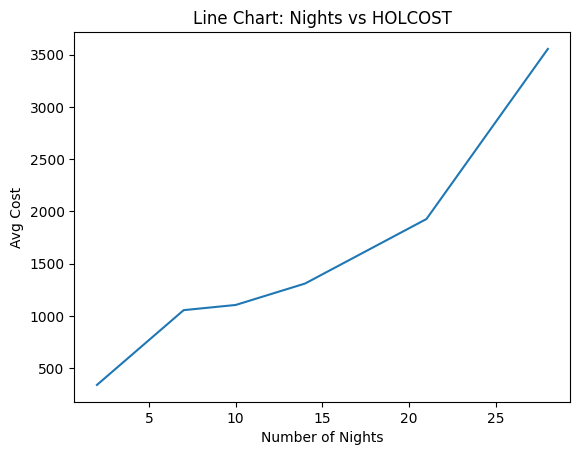

In [91]:
import matplotlib.pyplot as plt

avg_cost = (
    CustandHol_clean
    .groupby("NIGHTS")["HOLCOST_1"]
    .mean()
    .reset_index()
)

plt.plot(avg_cost['NIGHTS'], avg_cost['HOLCOST_1'])
plt.xlabel("Number of Nights")
plt.ylabel("Avg Cost")
plt.title("Line Chart: Nights vs HOLCOST")
plt.show()

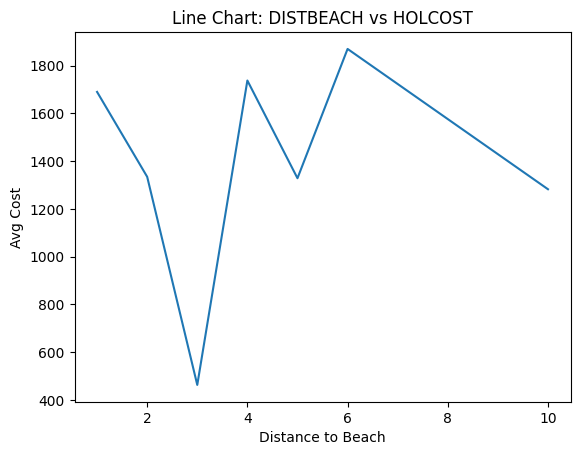

In [92]:
avg_cost = (
    CustandHol_clean
    .groupby("DISTBEACH")["HOLCOST_1"]
    .mean()
    .reset_index()
)

plt.plot(avg_cost['DISTBEACH'], avg_cost['HOLCOST_1'])
plt.xlabel("Distance to Beach")
plt.ylabel("Avg Cost")
plt.title("Line Chart: DISTBEACH vs HOLCOST")
plt.show()

In [95]:
#Create a new discrete version of HOLCOST variable with fixed size.  How many records are equal or
#greater than 2000

CustandHol_clean["HOLCOST_bins"] = pd.qcut(
    CustandHol_clean["HOLCOST_1"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

In [96]:
CustandHol_clean["HOLCOST_bins"].value_counts()

,count
HOLCOST_bins,
Low,36
Very High,36
Medium,35
High,35


In [98]:
(CustandHol_clean["HOLCOST_1"] >= 2000).sum()

np.int64(31)

In [100]:
CustandHol_clean["HOLCOST_1"].describe()

,HOLCOST_1
count,142.000000
mean,1363.028169
std,968.280804
min,239.000000
25%,512.500000
50%,1185.000000
75%,1807.500000
max,4260.000000


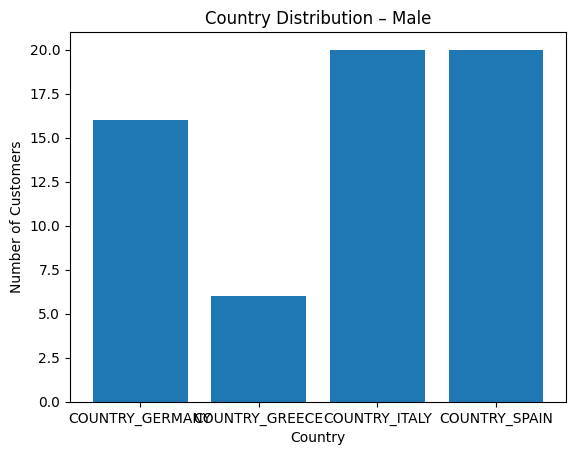

In [103]:
#Combine variables GENDER and COUNTRY. Do you see any difference between genders?

male_df = CustandHol_clean[CustandHol_clean["Gender_type"] == "Male"]

male_counts = male_df[
    ["COUNTRY_GERMANY", "COUNTRY_GREECE", "COUNTRY_ITALY", "COUNTRY_SPAIN"]
].sum()

plt.bar(male_counts.index, male_counts.values)
plt.title("Country Distribution – Male")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.show()

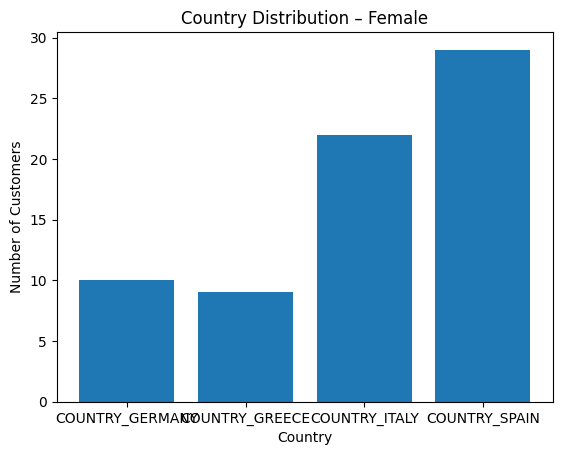

In [104]:
female_df = CustandHol_clean[CustandHol_clean["Gender_type"] == "Female"]

female_counts = female_df[
    ["COUNTRY_GERMANY", "COUNTRY_GREECE", "COUNTRY_ITALY", "COUNTRY_SPAIN"]
].sum()

plt.bar(female_counts.index, female_counts.values)
plt.title("Country Distribution – Female")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.show()

In [105]:
CustandHol_clean["GENDER_COUNTRY"] = (
    CustandHol_clean["Gender_type"].astype(str)
    + "_"
    + CustandHol_clean["COUNTRY"].astype(str)
)

In [109]:
#Show mean value of HOLCOST for each combination of GENDER and COUNTRY

CustandHol_clean.groupby("GENDER_COUNTRY").agg({"HOLCOST_1":["mean","count"]})

HOLCOST_1      
                       mean count
GENDER_COUNTRY                   
Female_GERMANY  1551.000000    12
Female_GREECE   1240.125000     8
Female_ITALY    1221.590909    22
Female_SPAIN     931.250000    32
Male_GERMANY    1202.750000    16
Male_GREECE     1603.750000     8
Male_ITALY      1982.521739    23
Male_SPAIN      1501.500000    20
nan_GERMANY      640.000000     1
nan_nan                 NaN     0

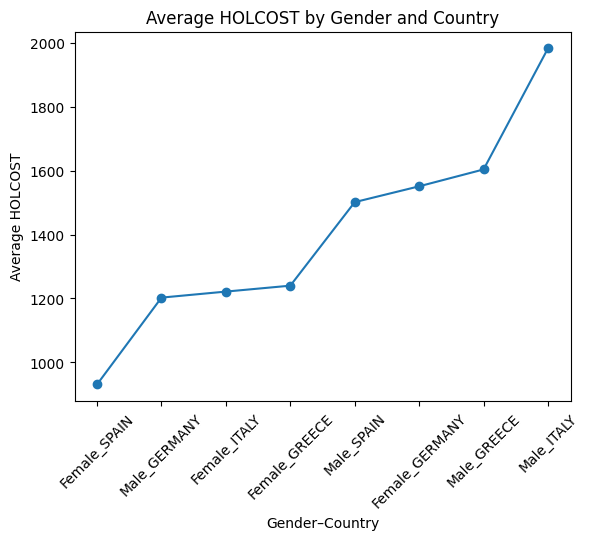

In [110]:
summary_df = CustandHol_clean.groupby("GENDER_COUNTRY")["HOLCOST_1"].agg(
    mean="mean",
    count="count"
).reset_index()

summary_df_clean = summary_df[
    ~summary_df["GENDER_COUNTRY"].str.contains("nan", case=False, na=False)
]

summary_df_clean = summary_df_clean.sort_values(by="mean")

plt.plot(
    summary_df_clean["GENDER_COUNTRY"],
    summary_df_clean["mean"],
    marker="o"
)

plt.xlabel("Gender–Country")
plt.ylabel("Average HOLCOST")
plt.title("Average HOLCOST by Gender and Country")
plt.xticks(rotation=45)
plt.show()

In [111]:
#Bin the variable HOLCOST using the ACCOMMODATION var with values either APARTMENT OR NOT

CustandHol_clean["ACCOMMODATION_BIN"] = np.where(
    CustandHol_clean["ACCOMMODATION"] == "APARTMENT",
    "APARTMENT",
    "NOT_APARTMENT"
)

In [115]:
CustandHol_clean[["ACCOMMODATION","ACCOMMODATION_BIN"]].head()

,ACCOMMODATION,ACCOMMODATION_BIN
0,HOTEL,NOT_APARTMENT
1,APARTMENT,APARTMENT
2,APARTMENT,APARTMENT
3,HOTEL,NOT_APARTMENT
4,APARTMENT,APARTMENT


In [117]:
CustandHol_clean.groupby("ACCOMMODATION_BIN")["HOLCOST_1"].mean()

,HOLCOST_1
ACCOMMODATION_BIN,
APARTMENT,1587.872727
NOT_APARTMENT,1220.885057
